# Liver Ultrasound Detection — EDA

What the data looks like, and why the test set is a different domain than train.
Figures are written to `../../assets/` for the README.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
sys.path.insert(0, '../src')
from liver_us.data import load_index, CLASSES
ASSETS = Path('../../../assets'); ASSETS.mkdir(exist_ok=True)
df = load_index('../datasets/index.csv')
df['source'] = df['source'].fillna('test (unlabelled)')
df['mobile_like'] = df.orig_w > 2048
df['positive'] = df.n_boxes > 0
df.shape

(24499, 14)

## 1. Splits, sources, positives

In [2]:
tab = df.groupby(['split', 'source']).agg(images=('image_id', 'size'), positives=('positive', 'sum'),
                                         mobile_like=('mobile_like', 'sum'))
tab['positive_rate'] = (tab.positives / tab.images).round(3)
tab

images  positives  mobile_like  positive_rate
split source                                                          
test  test (unlabelled)    5153          0         3152          0.000
train machine             13999       6999            0          0.500
      mobile                449        223          449          0.497
val   machine              3999       1999            0          0.500
      mobile                899        446          899          0.496

,machine,mobile
train,0.968923,0.031077
val,0.816456,0.183544
test,0.388317,0.611683


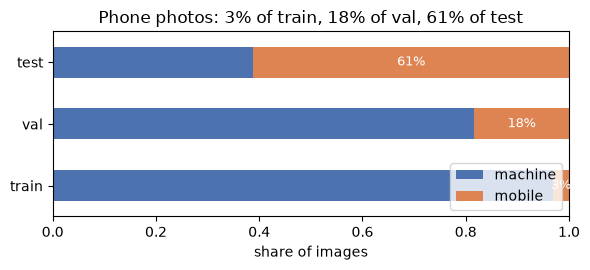

In [3]:
# Test composition: 4032x3024 originals are phone photos of the screen
comp = pd.DataFrame({
    'train': df[df.split=='train'].source.value_counts(normalize=True),
    'val': df[df.split=='val'].source.value_counts(normalize=True),
    'test': df[df.split=='test'].mobile_like.map({True: 'mobile', False: 'machine'}).value_counts(normalize=True)}).T.fillna(0)
fig, ax = plt.subplots(figsize=(6, 2.8))
comp[['machine', 'mobile']].plot.barh(stacked=True, ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_xlim(0, 1); ax.set_xlabel('share of images'); ax.set_title('Phone photos: 3% of train, 18% of val, 61% of test')
for i, (s, r) in enumerate(comp.iterrows()):
    ax.text(r.machine + r.mobile / 2, i, f"{r.mobile:.0%}", va='center', ha='center', color='white', fontsize=9)
ax.legend(loc='lower right'); plt.tight_layout(); plt.savefig(ASSETS / 'liver_us_domain_split.png', dpi=130); comp

## 2. Classes and box sizes

,count,25%,50%,75%
cls,,,,
FFC,1311.0,0.009535,0.017147,0.041337
FFS,2435.0,0.002712,0.004324,0.007183
HCC,2318.0,0.010463,0.021773,0.036813
cyst,1819.0,0.002314,0.003440,0.006046
hemangioma,1796.0,0.003315,0.005779,0.019037
dysplastic,797.0,0.003155,0.004534,0.006493
CCA,1143.0,0.001385,0.002886,0.008762


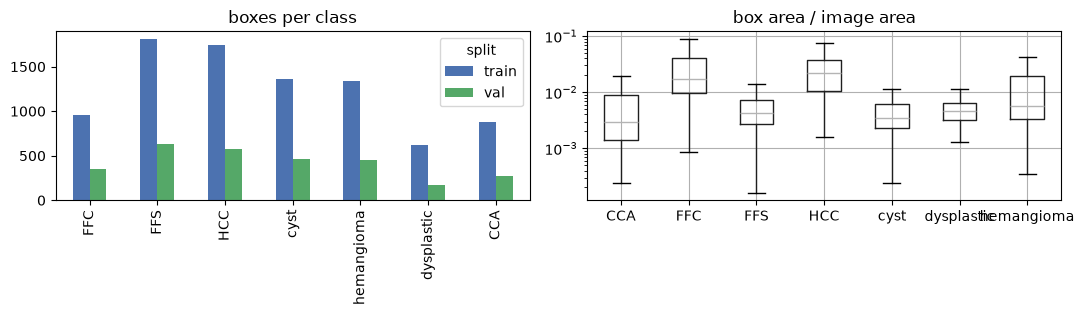

In [4]:
rows = []
for r in df[df.positive].itertuples():
    for line in Path(r.label_path).read_text().strip().splitlines():
        c, cx, cy, w, h = map(float, line.split())
        rows.append(dict(split=r.split, source=r.source, cls=CLASSES[int(c)], rel_w=w, rel_h=h, rel_area=w*h,
                         px_w=w*r.w, px_h=h*r.h))
boxes = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ct = boxes.groupby(['cls', 'split']).size().unstack().reindex(CLASSES)
ct.plot.bar(ax=axes[0], color=['#4c72b0', '#55a868']); axes[0].set_title('boxes per class'); axes[0].set_xlabel('')
boxes.boxplot(column='rel_area', by='cls', ax=axes[1], showfliers=False, positions=range(len(CLASSES)))
axes[1].set_yscale('log'); axes[1].set_title('box area / image area'); axes[1].set_xlabel(''); fig.suptitle('')
plt.tight_layout(); plt.savefig(ASSETS / 'liver_us_classes.png', dpi=130)
boxes.groupby('cls').rel_area.describe()[['count', '25%', '50%', '75%']].reindex(CLASSES)

In [5]:
# boxes per positive image and images with more than one class
n = df[df.positive].n_boxes.clip(upper=6).value_counts().sort_index()
multi = df[df.n_boxes > 1].classes.map(lambda s: len(set(s.split())) > 1)
print(n.to_dict()); print('multi-box images with >1 class:', int(multi.sum()), '/', len(multi))

{1: 8644, 2: 765, 3: 121, 4: 38, 5: 28, 6: 71}
multi-box images with >1 class: 127 / 1023


## 3. What a phone photo looks like next to a machine frame (and our simulation)

rows: machine frames / real phone photos / simulated phone photos


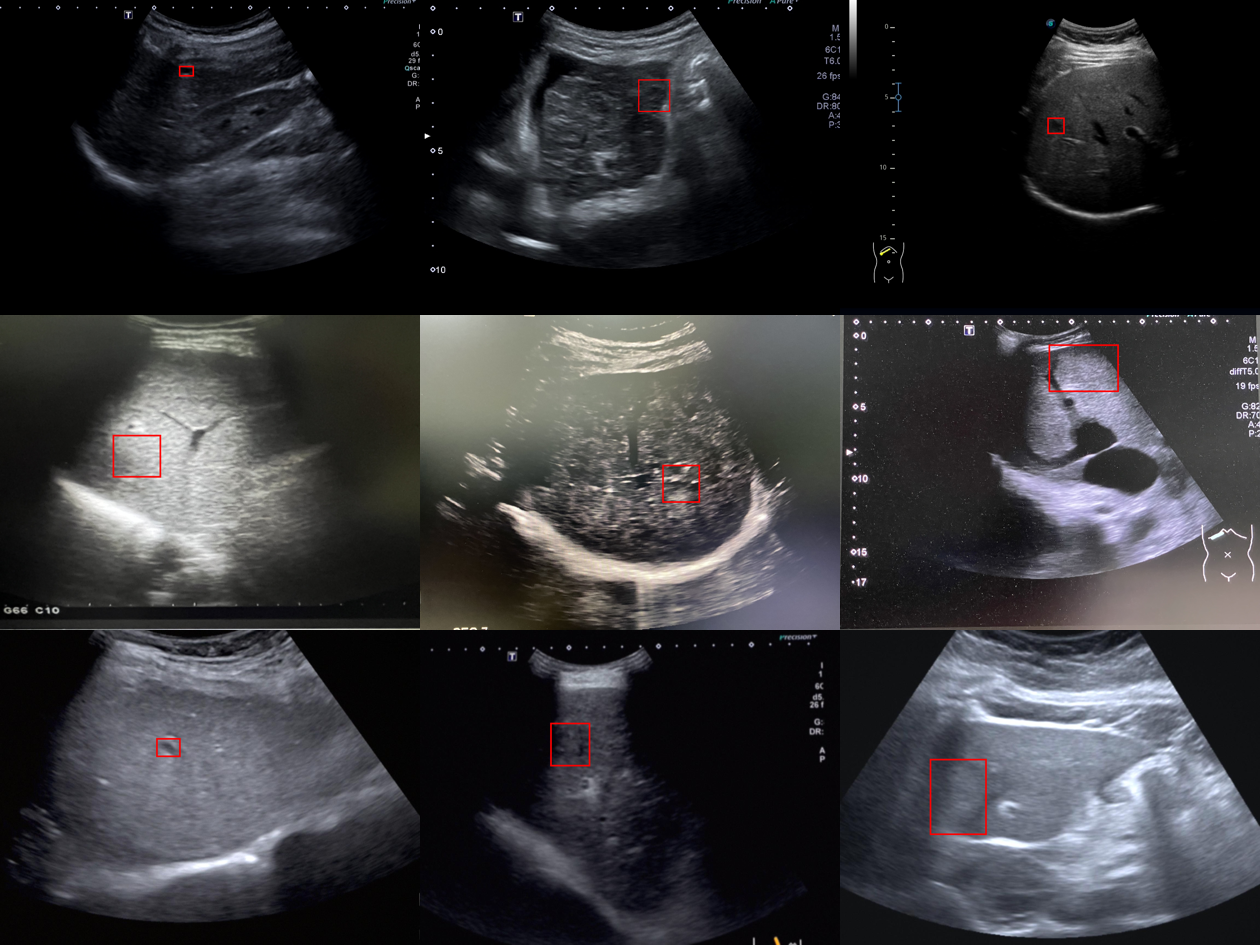

In [6]:
def draw(r, size=(420, 315)):
    im = Image.open(r.abs_path).convert('RGB'); W, H = im.size; d = ImageDraw.Draw(im)
    if isinstance(r.label_path, str) and r.label_path:
        for line in Path(r.label_path).read_text().strip().splitlines():
            c, cx, cy, w, h = map(float, line.split())
            d.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H], outline='red', width=max(2, W//250))
    im.thumbnail(size); return im
pos = df[(df.split=='train') & df.positive]
picks = list(pos[pos.source=='machine'].sample(3, random_state=7).itertuples()) + list(pos[pos.source=='mobile'].sample(3, random_state=7).itertuples())
synth = sorted(Path('../datasets/synth_v1/images').glob('*.jpg'))[:3] if Path('../datasets/synth_v1/images').exists() else []
sheet = Image.new('RGB', (3*420, (2 + bool(synth))*315), 'black')
for i, r in enumerate(picks):
    sheet.paste(draw(r), ((i%3)*420, (i//3)*315))
for i, p in enumerate(synth):
    lp = Path(str(p).replace('/images/', '/labels/')).with_suffix('.txt')
    class R: pass
    r = R(); r.abs_path = str(p); r.label_path = str(lp) if lp.exists() else ''
    sheet.paste(draw(r), (i*420, 2*315))
sheet.save(ASSETS / 'liver_us_samples.jpg', quality=88)
print('rows: machine frames / real phone photos' + (' / simulated phone photos' if synth else ''))
sheet

## 4. Why the metric changes the strategy

The submission has no confidence column, so the leaderboard mAP can only rank boxes by file order (or treat them as ties).
Every box we submit is therefore a permanent point on the precision–recall curve: AP per class ≈ recall × precision at one operating point.
`liver_us.metric` implements both readings (`ranked` = classic, `unranked` = scores tied) so thresholds can be tuned for the one that matters.